In [1]:
import os
import sys

project_root = "/root/work/tvm-ansor"
os.environ["TVM_HOME"] = f"{project_root}"
os.environ["TVM_LIBRARY_PATH"] = f"{project_root}/build-release"
if f"{project_root}/python" not in sys.path:
    sys.path.insert(0, f"{project_root}/python")

sys.path = [p for p in sys.path if not p.startswith(f"{project_root}/build")]
sys.path.append(f"{project_root}/build-release")
os.environ["LD_LIBRARY_PATH"] = f"{project_root}/build-release:" + os.environ.get("LD_LIBRARY_PATH", "")


import tvm

TARGET = tvm.target.Target("cuda")


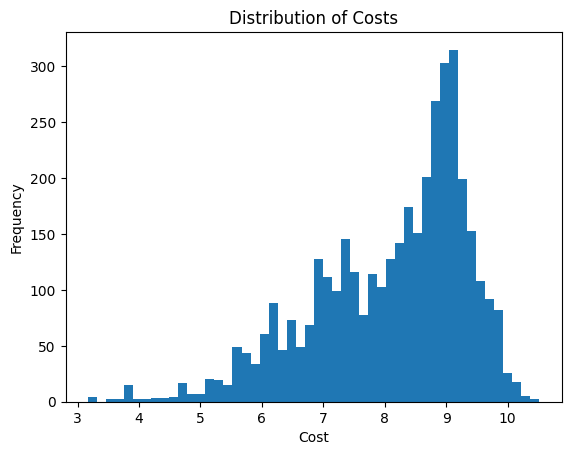

In [4]:
import numpy as np


from tvm import auto_scheduler
from util_modules.input.integrated import json_to_VecCosts
from util_modules.task_paths import load_and_register_tasks
import numpy as np
from util_modules.plot.latent_cost_geometry import plot_latent_cost_geometry
import importlib
importlib.reload(sys.modules["util_modules.plot.latent_cost_geometry"])

# json_file = "/root/work/tvm-ansor/gallery/constrained_gen/data/measured_ansor/584_([cb7a0e9e733d26ffc00e7f6c9cc0f879,[1,128,128,32],[1,1,32,16],[1,1,1,16],[1,128,128,16]],cuda).json"
json_file = "/root/work/tvm-ansor/gallery/constrained_gen/data/measured_ansor/1490_([3eda1939e30b947e921f5e1814346365,[1,56,56,128],[6,6,32,128],[1,56,56,32]],cuda).json"
tasks = load_and_register_tasks()

importlib.reload(sys.modules["util_modules.input.integrated"])

raw_sch, costs = json_to_VecCosts(json_file, type="schedules")
# raw_features, costs = json_to_VecCosts(json_file, type="features")
# features = raw_features.sum(axis=1)
# raw_extents, costs = json_to_VecCosts(json_file, type="extents")


from util_modules.plot.cost_dist import plot_cost_distribution

plot_cost_distribution(costs)